# 🎓 Öğrenci Performansı Analizi & Tahmin Modeli
> **Veri Seti:** Ultimate Student Productivity Dataset (5000 kayıt)  
> **Hedef Değişken:** `exam_score` (sürekli → Regresyon görevi)  
> **Yazar:** —  

---

## 1. Gerekli Kütüphanelerin Yüklenmesi

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from IPython.display import display
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Kaggle veri yolu
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Görsel stil
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
print('✅ Kütüphaneler başarıyla yüklendi.')

/kaggle/input/datasets/emirhankadan/student-productivity-1/ultimate_student_productivity_dataset_5000.csv
✅ Kütüphaneler başarıyla yüklendi.


## 2. Verinin Yüklenmesi

In [2]:
DATA_PATH ="/kaggle/input/datasets/emirhankadan/student-productivity-1/ultimate_student_productivity_dataset_5000.csv"
df = pd.read_csv(DATA_PATH)
print(f'Veri seti başarıyla yüklendi. Boyut: {df.shape}')

Veri seti başarıyla yüklendi. Boyut: (5000, 21)


## 3. Keşifçi Veri Analizi (EDA)
> **Hedef Değişken:** `exam_score` (sürekli — regresyon problemi)

In [3]:
df.head()

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,Good,8,38.11,39.53,59.23,27.81


In [4]:
print(f'Satır sayısı : {df.shape[0]}')
print(f'Sütun sayısı : {df.shape[1]}')

Satır sayısı : 5000
Sütun sayısı : 21


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   object 
 3   academic_level        5000 non-null   object 
 4   study_hours           5000 non-null   float64
 5   self_study_hours      5000 non-null   float64
 6   online_classes_hours  5000 non-null   float64
 7   social_media_hours    5000 non-null   float64
 8   gaming_hours          5000 non-null   float64
 9   sleep_hours           5000 non-null   float64
 10  screen_time_hours     5000 non-null   float64
 11  exercise_minutes      5000 non-null   int64  
 12  caffeine_intake_mg    5000 non-null   int64  
 13  part_time_job         5000 non-null   int64  
 14  upcoming_deadline     5000 non-null   int64  
 15  internet_quality     

In [6]:
print('=== Temel İstatistikler ===')
display(df.describe())

=== Temel İstatistikler ===


,student_id,age,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,20.520400,4.539594,2.478734,2.011984,2.998086,1.564514,7.016492,6.979588,74.535600,251.450400,0.498200,0.501400,5.507400,29.431616,45.615324,37.267716,18.803752
std,1443.520003,2.870406,1.821665,1.177990,0.983906,1.467949,1.110807,1.163692,2.486214,42.932293,143.842712,0.500047,0.500048,2.869145,9.962902,14.246591,16.849397,12.130840
min,1.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1250.750000,18.000000,3.250000,1.660000,1.320000,1.990000,0.670000,6.237500,5.280000,37.000000,129.000000,0.000000,0.000000,3.000000,22.567500,35.727500,25.290000,9.337500
50%,2500.500000,20.000000,4.530000,2.480000,2.010000,2.980000,1.490000,7.010000,6.950000,75.000000,252.000000,0.000000,1.000000,5.000000,29.430000,45.690000,36.860000,18.010000
75%,3750.250000,23.000000,5.760000,3.290000,2.690000,4.030000,2.340000,7.810000,8.710000,112.000000,376.000000,1.000000,1.000000,8.000000,36.242500,55.352500,49.142500,27.400000
max,5000.000000,25.000000,11.840000,7.410000,6.000000,8.280000,5.640000,10.000000,15.300000,149.000000,499.000000,1.000000,1.000000,10.000000,63.480000,97.580000,98.020000,64.090000


In [7]:
missing = df.isnull().sum()
print('=== Eksik Değer Kontrolü ===')
print(missing[missing > 0] if missing.any() else 'Eksik değer bulunamadı. ✅')

=== Eksik Değer Kontrolü ===
Eksik değer bulunamadı. ✅


### 3.1 Hedef Değişken Dağılımı — `exam_score`

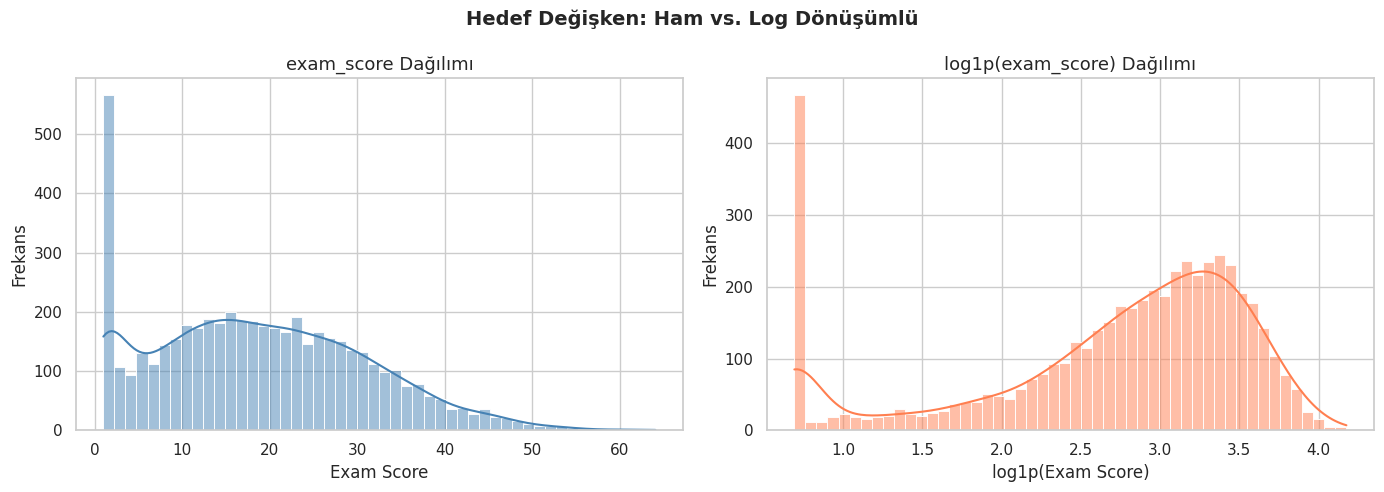

Çarpıklık (skewness): 0.3761
Basıklık  (kurtosis): -0.4472
Çarpıklık (skewness): -1.0484
Basıklık  (kurtosis): 0.1640


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram + KDE
sns.histplot(df['exam_score'], kde=True, bins=50, color='steelblue', ax=axes[0])
axes[0].set_title('exam_score Dağılımı', fontsize=13)
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Frekans')

# Log1p dönüşümü (sağa çarpık dağılım için)
sns.histplot(np.log1p(df['exam_score']), kde=True, bins=50, color='coral', ax=axes[1])
axes[1].set_title('log1p(exam_score) Dağılımı', fontsize=13)
axes[1].set_xlabel('log1p(Exam Score)')
axes[1].set_ylabel('Frekans')

plt.suptitle('Hedef Değişken: Ham vs. Log Dönüşümlü', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Çarpıklık (skewness): {df["exam_score"].skew():.4f}')
print(f'Basıklık  (kurtosis): {df["exam_score"].kurt():.4f}')
print(f'Çarpıklık (skewness): {np.log1p(df["exam_score"]).skew():.4f}')
print(f'Basıklık  (kurtosis): {np.log1p(df["exam_score"]).kurt():.4f}')

### 3.2 Nümerik ve Kategorik Sütunların Belirlenmesi

In [9]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f'Nümerik sütunlar ({len(numerical_cols)})  : {numerical_cols}')
print(f'Kategorik sütunlar ({len(categorical_cols)}): {categorical_cols}')

Nümerik sütunlar (18)  : ['student_id', 'age', 'study_hours', 'self_study_hours', 'online_classes_hours', 'social_media_hours', 'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes', 'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline', 'mental_health_score', 'focus_index', 'burnout_level', 'productivity_score', 'exam_score']
Kategorik sütunlar (3): ['gender', 'academic_level', 'internet_quality']


### 3.3 Nümerik Değişkenlerin Dağılımı (Histogram & Boxplot)

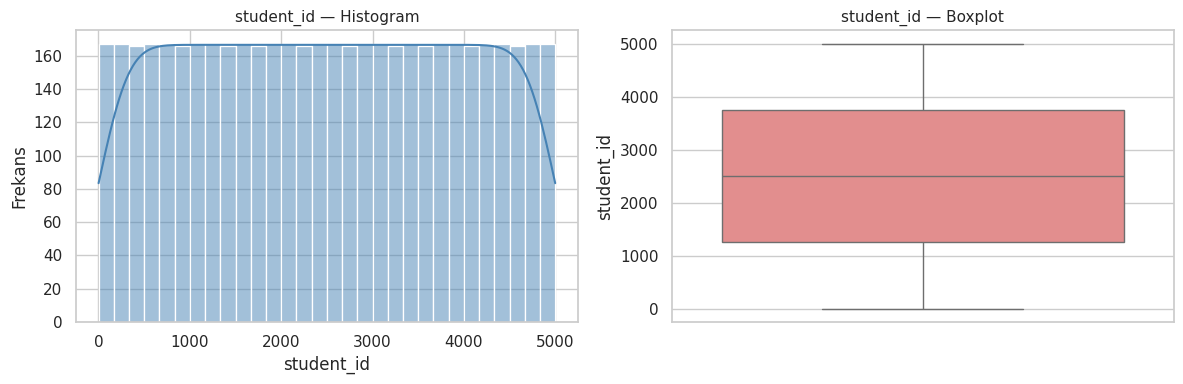

Çarpıklık (skewness): 0.0000
Basıklık  (kurtosis): -1.2000


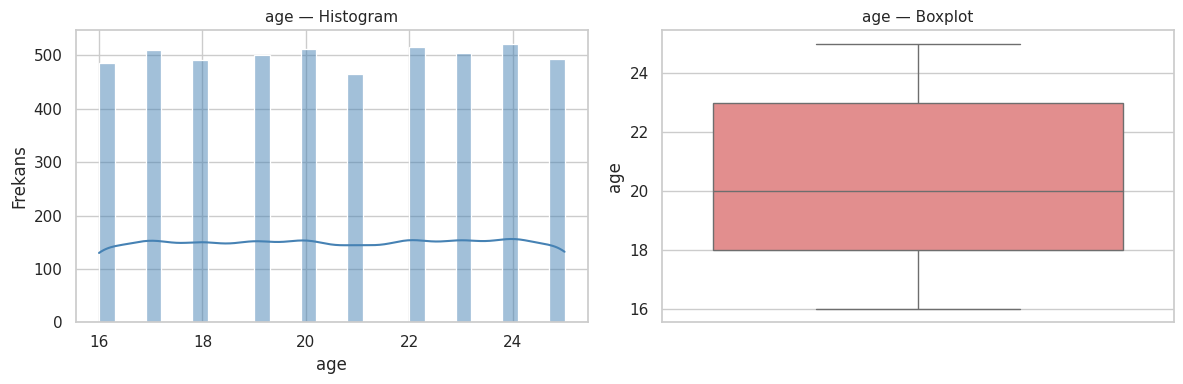

Çarpıklık (skewness): -0.0092
Basıklık  (kurtosis): -1.2321


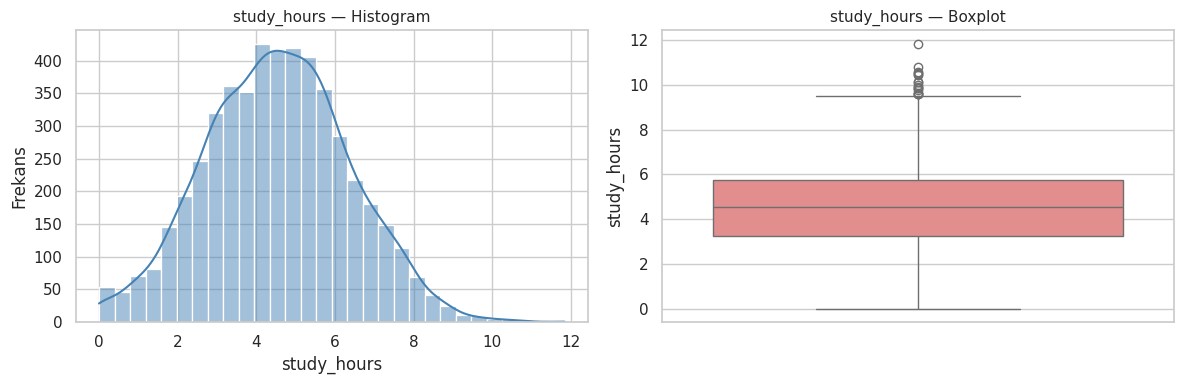

Çarpıklık (skewness): 0.0572
Basıklık  (kurtosis): -0.1502


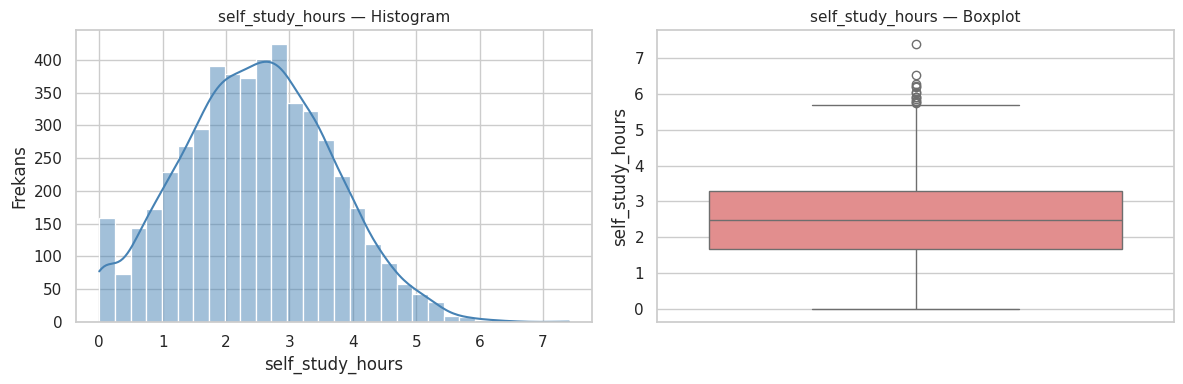

Çarpıklık (skewness): 0.0929
Basıklık  (kurtosis): -0.2851


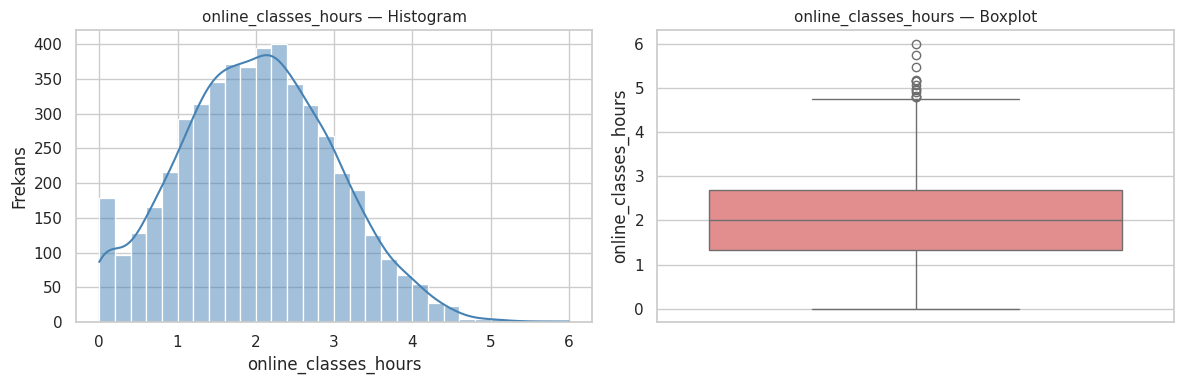

Çarpıklık (skewness): 0.1285
Basıklık  (kurtosis): -0.2706


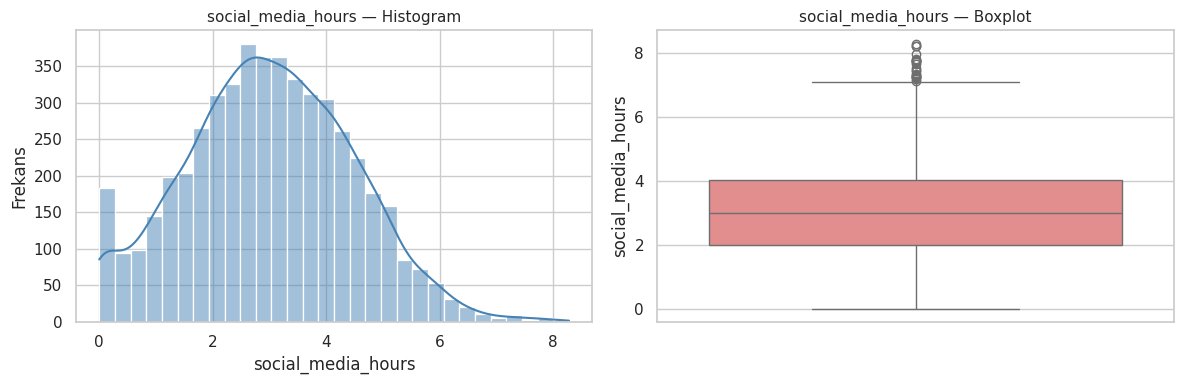

Çarpıklık (skewness): 0.1140
Basıklık  (kurtosis): -0.2099


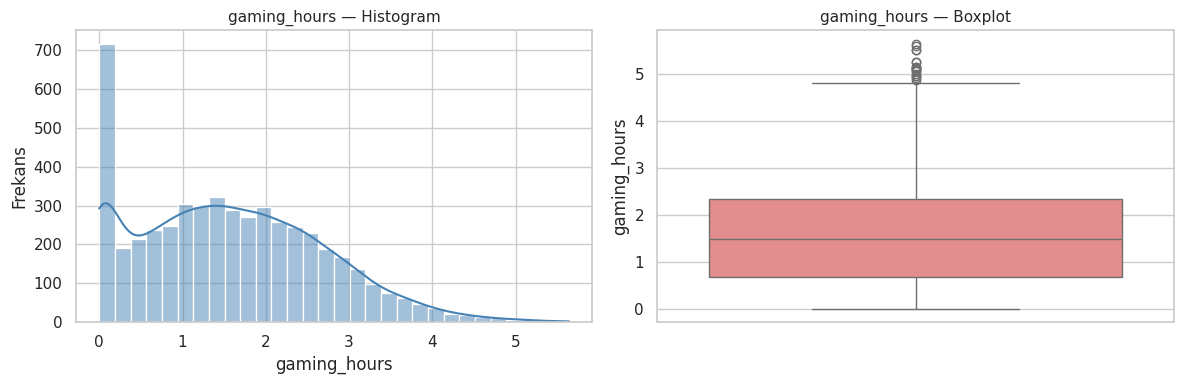

Çarpıklık (skewness): 0.4316
Basıklık  (kurtosis): -0.3437


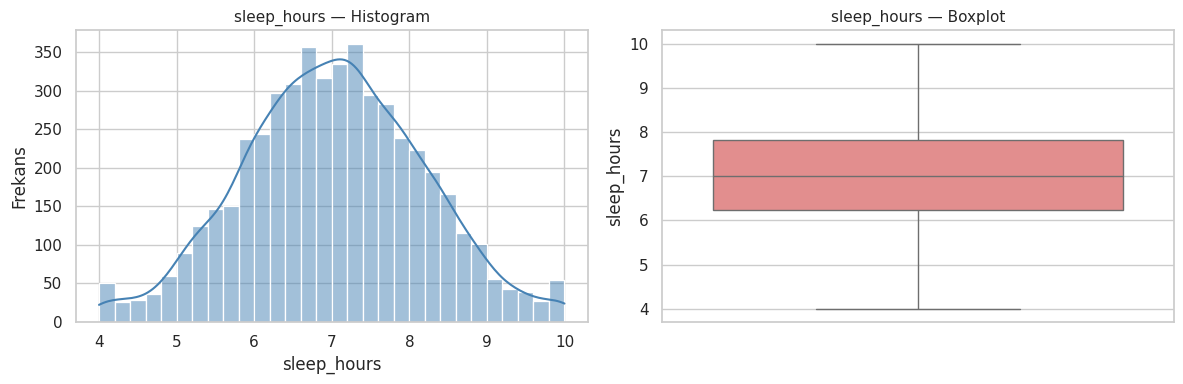

Çarpıklık (skewness): 0.0074
Basıklık  (kurtosis): -0.1457


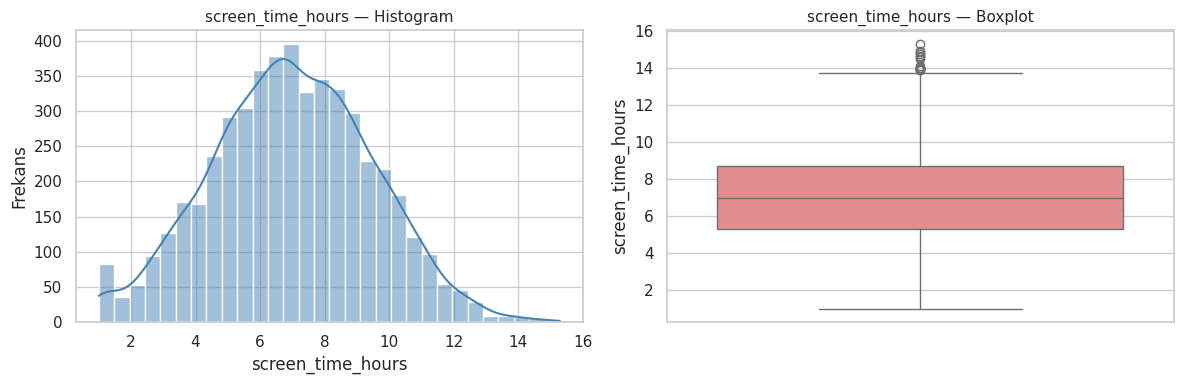

Çarpıklık (skewness): 0.0012
Basıklık  (kurtosis): -0.2321


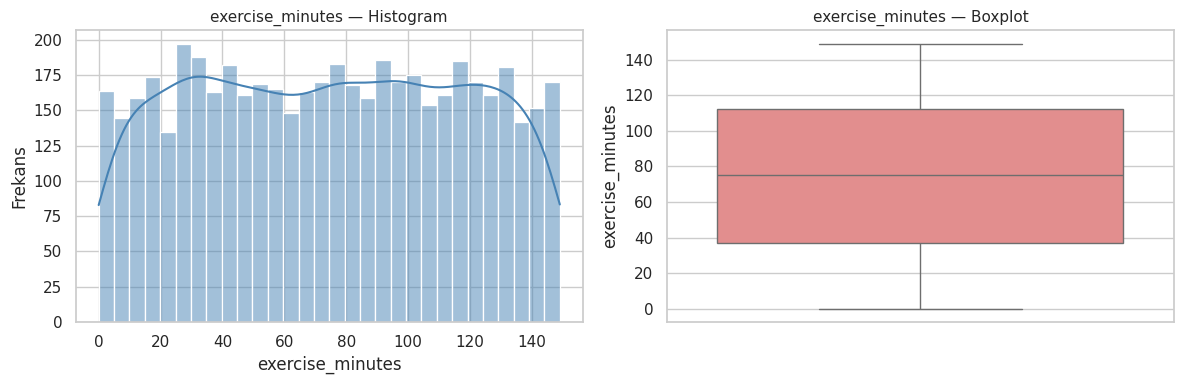

Çarpıklık (skewness): -0.0003
Basıklık  (kurtosis): -1.1894


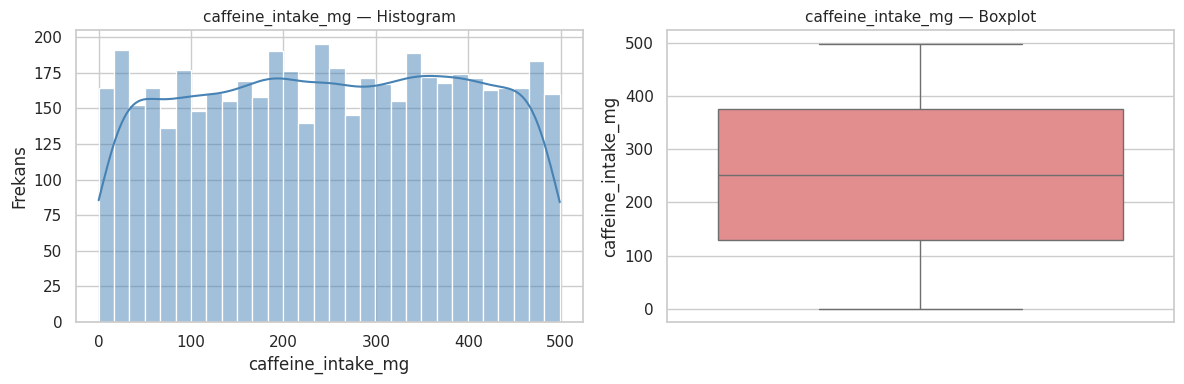

Çarpıklık (skewness): -0.0274
Basıklık  (kurtosis): -1.1886


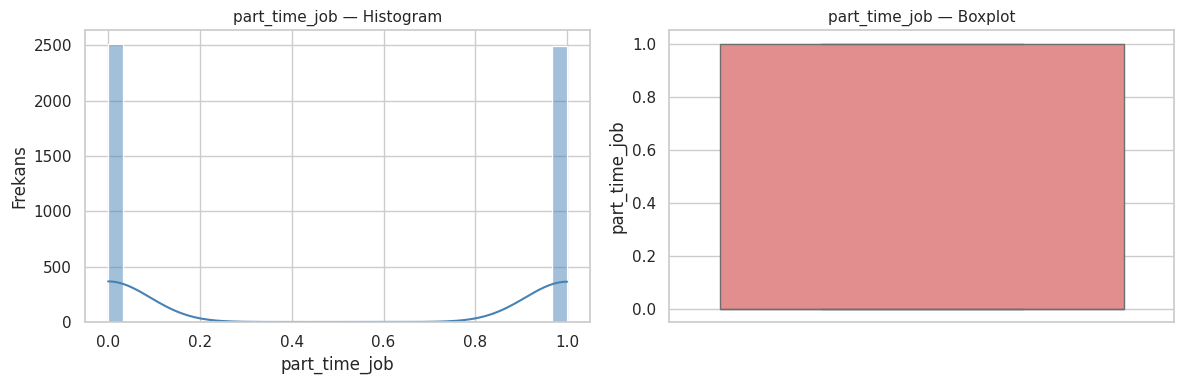

Çarpıklık (skewness): 0.0072
Basıklık  (kurtosis): -2.0007


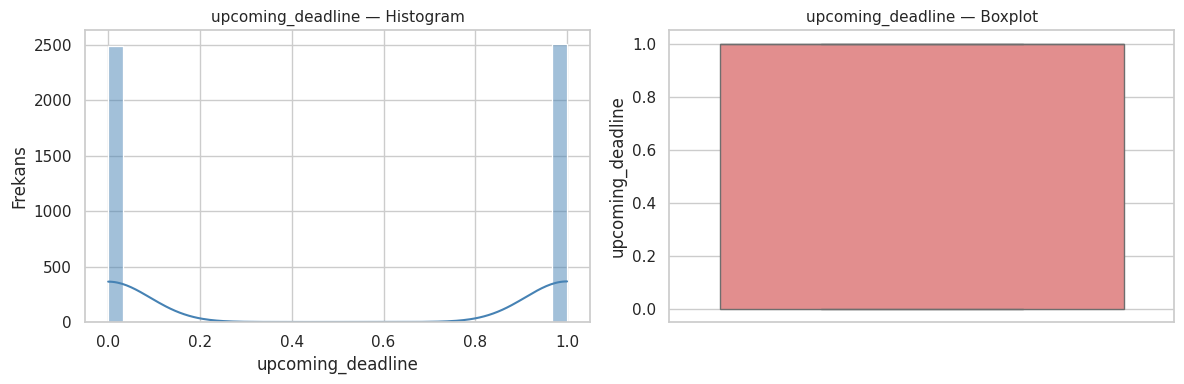

Çarpıklık (skewness): -0.0056
Basıklık  (kurtosis): -2.0008


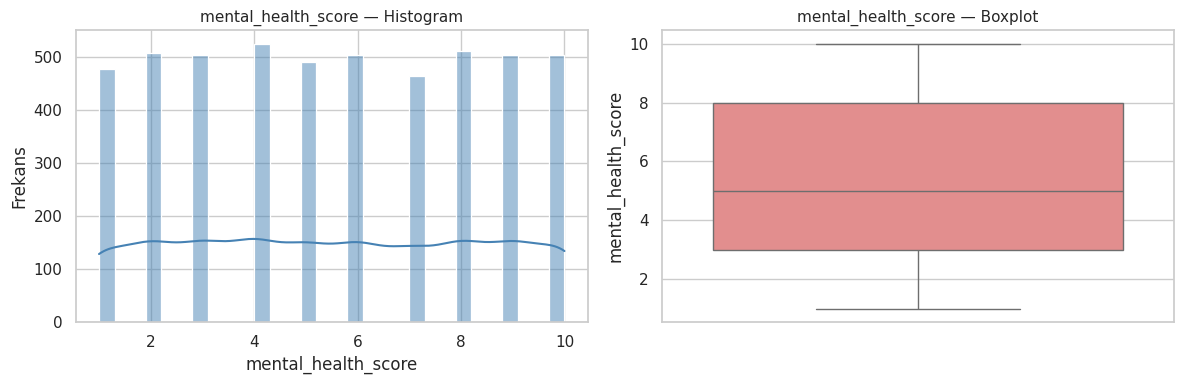

Çarpıklık (skewness): 0.0098
Basıklık  (kurtosis): -1.2288


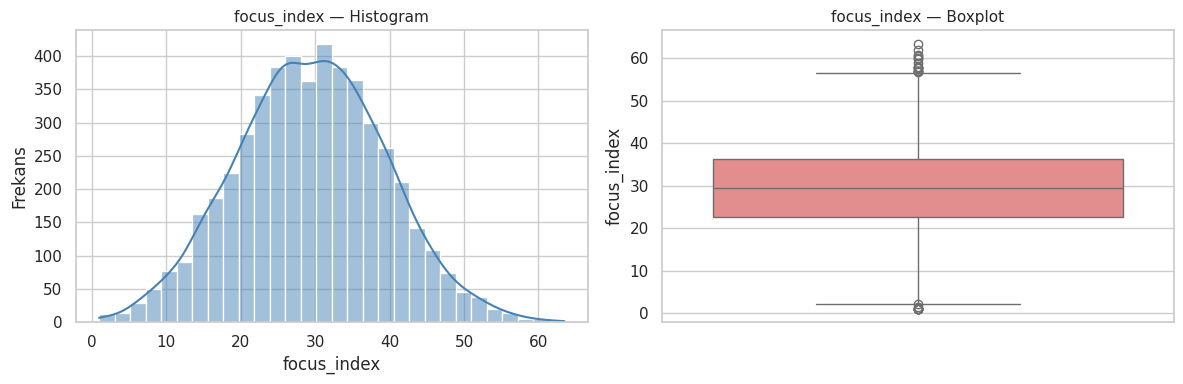

Çarpıklık (skewness): 0.0321
Basıklık  (kurtosis): -0.1619


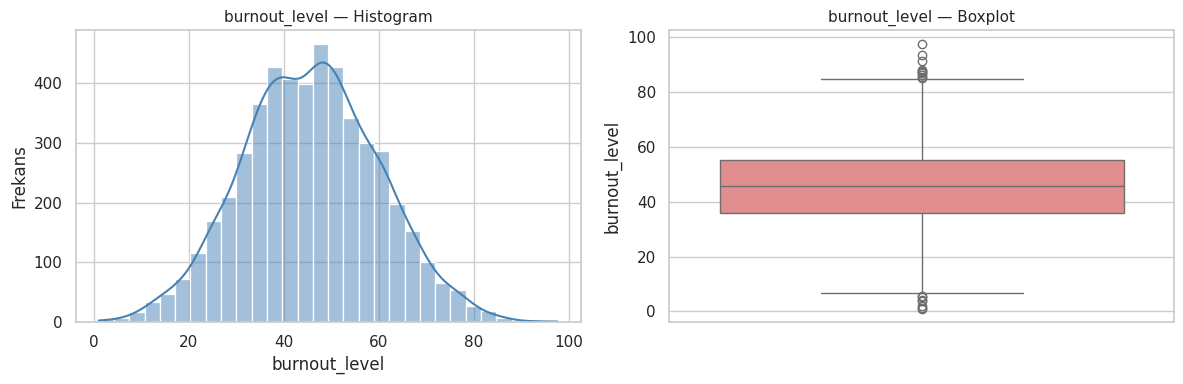

Çarpıklık (skewness): 0.0476
Basıklık  (kurtosis): -0.1639


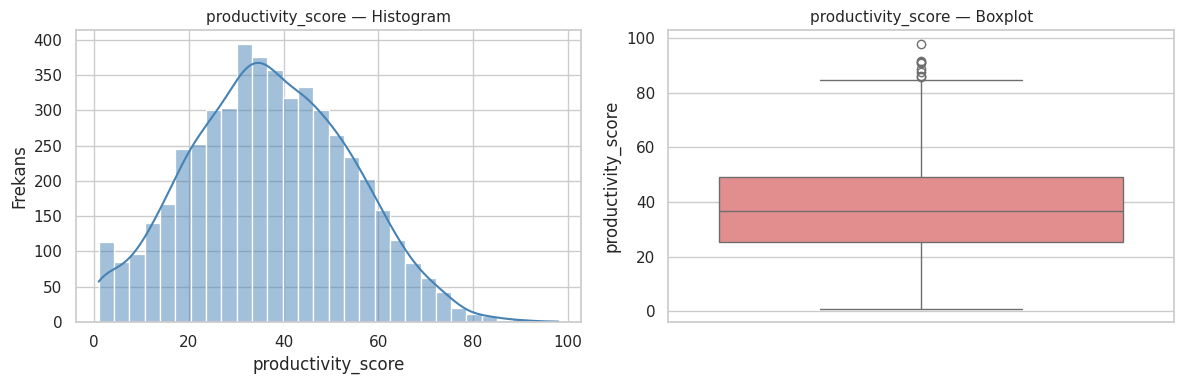

Çarpıklık (skewness): 0.0897
Basıklık  (kurtosis): -0.3764


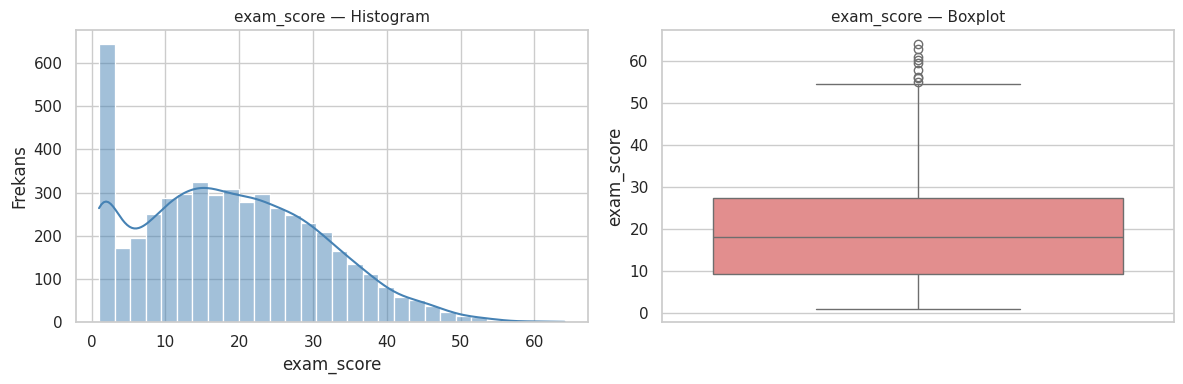

Çarpıklık (skewness): 0.3761
Basıklık  (kurtosis): -0.4472


In [10]:
for col in numerical_cols:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(df[col].dropna(), bins=30, kde=True, color='steelblue', ax=ax[0])
    ax[0].set_title(f'{col} — Histogram', fontsize=11)
    ax[0].set_xlabel(col)
    ax[0].set_ylabel('Frekans')

    sns.boxplot(y=df[col].dropna(), color='lightcoral', ax=ax[1])
    ax[1].set_title(f'{col} — Boxplot', fontsize=11)
    ax[1].set_ylabel(col)

    plt.tight_layout()
    plt.show()
    print(f'Çarpıklık (skewness): {df[col].skew():.4f}')
    print(f'Basıklık  (kurtosis): {df[col].kurt():.4f}')

### 3.4 Kategorik Değişkenler — Frekans & Exam Score Dağılımı

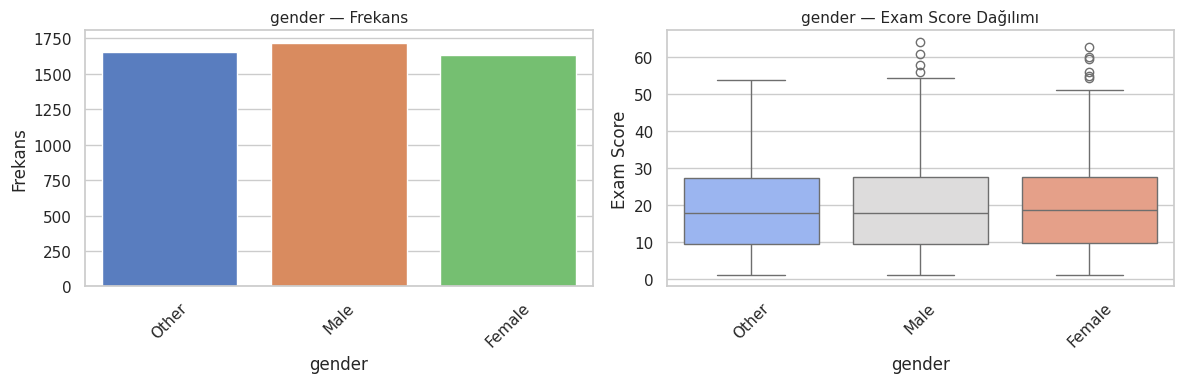

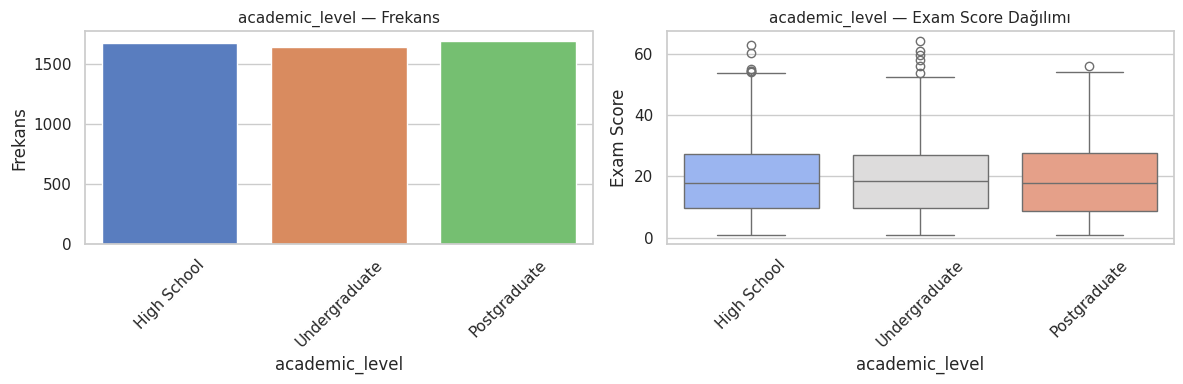

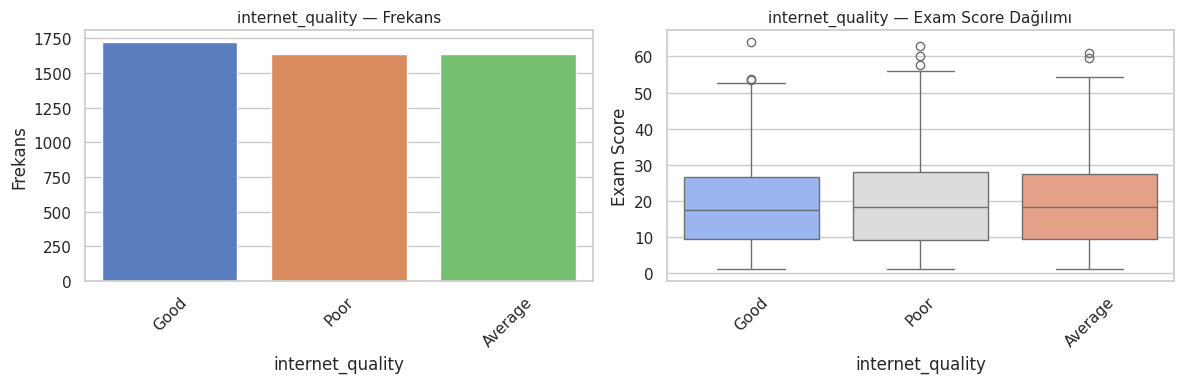

In [11]:
for col in categorical_cols:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    sns.countplot(x=col, data=df, ax=ax[0], palette='muted')
    ax[0].set_title(f'{col} — Frekans', fontsize=11)
    ax[0].set_xlabel(col)
    ax[0].set_ylabel('Frekans')
    ax[0].tick_params(axis='x', rotation=45)

    sns.boxplot(x=col, y='exam_score', data=df, ax=ax[1], palette='coolwarm')
    ax[1].set_title(f'{col} — Exam Score Dağılımı', fontsize=11)
    ax[1].set_xlabel(col)
    ax[1].set_ylabel('Exam Score')
    ax[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

### 3.5 Feature Başına Unique Değer Sayısı

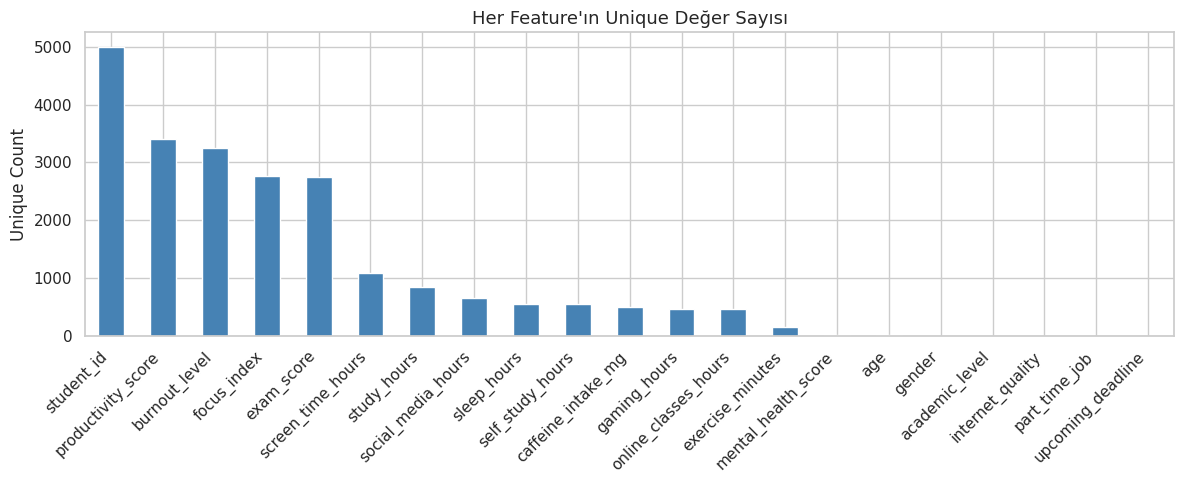

In [12]:
unique_counts = df.nunique().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
unique_counts.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title("Her Feature'ın Unique Değer Sayısı", fontsize=13)
plt.ylabel('Unique Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3.6 Aykırı Değer (Outlier) Analizi — IQR Yöntemi

In [13]:
outlier_report = {}
outlier_ratio  = {}

for col in numerical_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report[col] = count
    outlier_ratio[col]  = count / len(df)

outlier_df = pd.DataFrame({
    'Aykırı Sayısı': pd.Series(outlier_report),
    'Aykırı Oranı (%)': (pd.Series(outlier_ratio) * 100).round(2)
}).sort_values('Aykırı Sayısı', ascending=False)

display(outlier_df)
print(f'\nAykırı değer içeren özellik sayısı: {(outlier_df["Aykırı Sayısı"] > 0).sum()}')

,Aykırı Sayısı,Aykırı Oranı (%)
focus_index,24,0.48
social_media_hours,22,0.44
gaming_hours,18,0.36
study_hours,17,0.34
burnout_level,17,0.34
screen_time_hours,15,0.30
online_classes_hours,13,0.26
self_study_hours,13,0.26
exam_score,9,0.18
productivity_score,8,0.16



Aykırı değer içeren özellik sayısı: 10


### 3.7 Korelasyon Analizi — exam_score ile En Yüksek İlişkili Özellikler

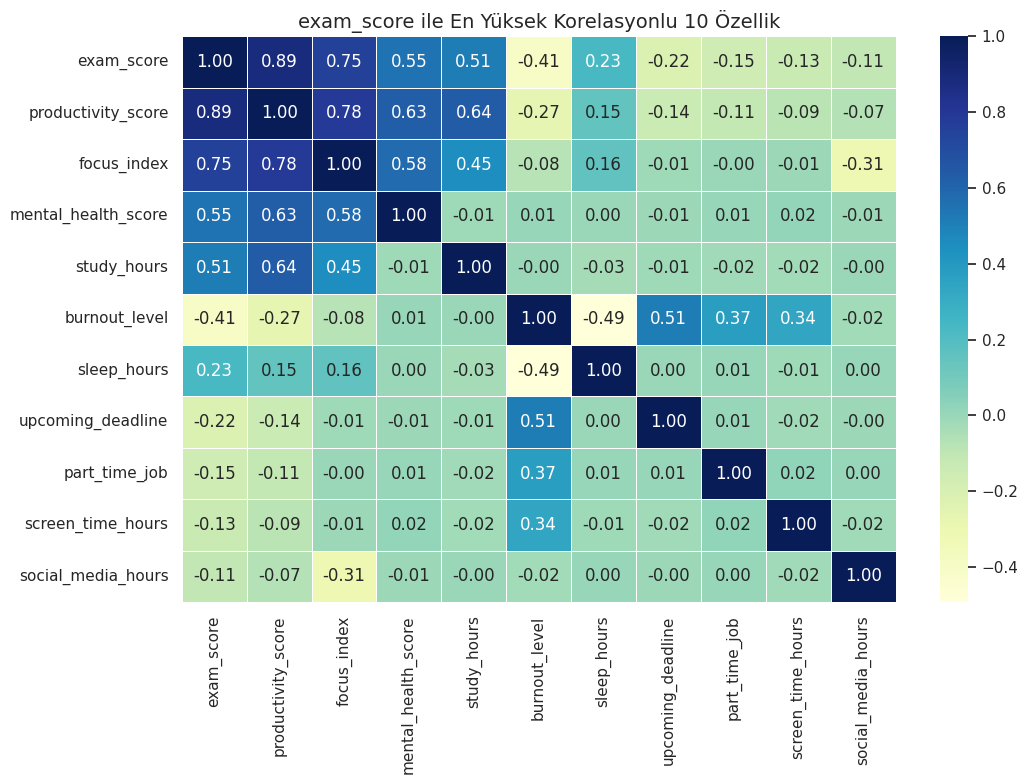

exam_score Korelasyon Sıralaması:
exam_score              1.000000
productivity_score      0.886401
focus_index             0.749879
mental_health_score     0.546547
study_hours             0.513434
burnout_level           0.407808
sleep_hours             0.234710
upcoming_deadline       0.215342
part_time_job           0.149807
screen_time_hours       0.131940
social_media_hours      0.106116
self_study_hours        0.083602
caffeine_intake_mg      0.075586
gaming_hours            0.054506
exercise_minutes        0.040724
student_id              0.029406
age                     0.009047
online_classes_hours    0.004975
Name: exam_score, dtype: float64


In [14]:
corr_matrix = df.corr(numeric_only=True)
top_corr = corr_matrix['exam_score'].abs().sort_values(ascending=False).head(11)

plt.figure(figsize=(11, 8))
sns.heatmap(
    df[top_corr.index].corr(),
    annot=True, cmap='YlGnBu', fmt='.2f',
    linewidths=0.5, linecolor='white'
)
plt.title('exam_score ile En Yüksek Korelasyonlu 10 Özellik', fontsize=14)
plt.tight_layout()
plt.show()

print('exam_score Korelasyon Sıralaması:')
print(corr_matrix['exam_score'].abs().sort_values(ascending=False))

## 4. Feature Engineering & Ön İşleme
Yapılacaklar:
- `student_id` ve `caffeine_intake_mg` düşür
- `self_study_hours`, `study_hours`, `online_classes_hours` → `total_study_hours` olarak birleştir
- `social_media_hours` + `screen_time_hours` → `screen_time_hours` (güncellenmiş)
- `exam_score` ve `gaming_hours` → RobustScaler (aykırı değerlere karşı)
- Diğer nümerik sütunlar → StandardScaler
- Kategorik sütunlar → One-Hot Encoding

In [15]:
df_proc = df.copy()

# ── Gereksiz sütunları düşür
df_proc.drop(columns=['student_id', 'caffeine_intake_mg'], inplace=True)

# ── Feature birleştirme
df_proc['total_study_hours'] = (
    df_proc['study_hours']
    + df_proc['self_study_hours']
    + df_proc['online_classes_hours']
)
df_proc.drop(columns=['study_hours', 'self_study_hours', 'online_classes_hours'], inplace=True)

# ── Ekran süresi birleştirme
df_proc['screen_time_hours'] = df_proc['screen_time_hours'] + df_proc['social_media_hours']
df_proc.drop(columns=['social_media_hours'], inplace=True)

# ── One-Hot Encoding
df_proc = pd.get_dummies(df_proc, drop_first=True)

print(f'İşlenmiş veri seti boyutu: {df_proc.shape}')
print(f'Sütunlar: {df_proc.columns.tolist()}')

İşlenmiş veri seti boyutu: (5000, 19)
Sütunlar: ['age', 'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes', 'part_time_job', 'upcoming_deadline', 'mental_health_score', 'focus_index', 'burnout_level', 'productivity_score', 'exam_score', 'total_study_hours', 'gender_Male', 'gender_Other', 'academic_level_Postgraduate', 'academic_level_Undergraduate', 'internet_quality_Good', 'internet_quality_Poor']


## 5. Eğitim / Test Ayrımı ve Ölçekleme

In [16]:
TARGET = 'exam_score'
X = df_proc.drop(columns=[TARGET])
y = df_proc[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# RobustScaler — aykırı değer içeren sütunlar (gaming_hours)
robust_cols = ['gaming_hours']
robust_scaler = RobustScaler()
X_train[robust_cols] = robust_scaler.fit_transform(X_train[robust_cols])
X_test[robust_cols]  = robust_scaler.transform(X_test[robust_cols])

# StandardScaler — diğer nümerik sütunlar
standard_cols = [c for c in X_train.select_dtypes(include='number').columns if c not in robust_cols]
std_scaler = StandardScaler()
X_train[standard_cols] = std_scaler.fit_transform(X_train[standard_cols])
X_test[standard_cols]  = std_scaler.transform(X_test[standard_cols])

print(f'Eğitim seti : {X_train.shape}')
print(f'Test seti   : {X_test.shape}')

Eğitim seti : (4000, 18)
Test seti   : (1000, 18)


## 6. Model Eğitimi ve Karşılaştırması
Değerlendirme metrikleri: **RMSE**, **MAE**, **R²**

In [17]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    rmse  = np.sqrt(mean_squared_error(y_te, preds))
    mae   = mean_absolute_error(y_te, preds)
    r2    = r2_score(y_te, preds)
    return {'Model': name, 'RMSE': round(rmse, 4), 'MAE': round(mae, 4), 'R²': round(r2, 4)}

models = {
    'Linear Regression'          : LinearRegression(),
    'Ridge'                      : Ridge(alpha=1.0),
    'Lasso'                      : Lasso(alpha=0.01),
    'Decision Tree'              : DecisionTreeRegressor(random_state=42),
    'KNN'                        : KNeighborsRegressor(n_neighbors=5),
    'Random Forest'              : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting'          : GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost'                    : XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
}

results = [evaluate(name, mdl, X_train, y_train, X_test, y_test)
           for name, mdl in models.items()]

results_df = pd.DataFrame(results).sort_values('R²', ascending=False).reset_index(drop=True)
display(results_df)
print(f'\n🏆 En iyi model: {results_df.iloc[0]["Model"]}  (R² = {results_df.iloc[0]["R²"]})')

,Model,RMSE,MAE,R²
0,Gradient Boosting,4.9690,3.9233,0.8188
1,Lasso,4.9914,3.9544,0.8172
2,Ridge,4.9988,3.9602,0.8166
3,Linear Regression,4.9989,3.9603,0.8166
4,Random Forest,5.0461,3.9899,0.8131
5,XGBoost,5.5081,4.3302,0.7773
6,KNN,6.1269,4.8258,0.7245
7,Decision Tree,7.0578,5.4912,0.6344



🏆 En iyi model: Gradient Boosting  (R² = 0.8188)


### 6.1 Model Performans Karşılaştırması (Görsel)

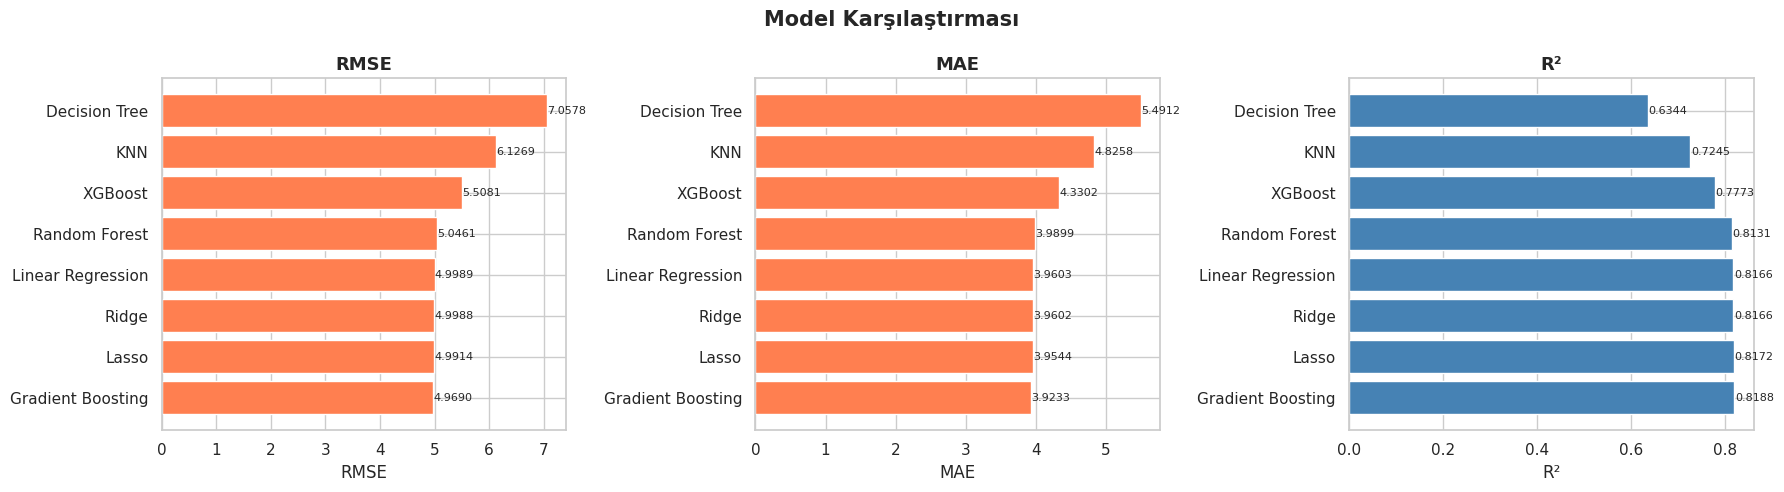

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, ['RMSE', 'MAE', 'R²']):
    ascending = metric != 'R²'
    data = results_df.sort_values(metric, ascending=ascending)
    bars = ax.barh(data['Model'], data[metric],
                   color='steelblue' if metric == 'R²' else 'coral',
                   edgecolor='white')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xlabel(metric)
    for bar, val in zip(bars, data[metric]):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=8)

plt.suptitle('Model Karşılaştırması', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.2 En İyi Modelin Gerçek vs. Tahmin Karşılaştırması

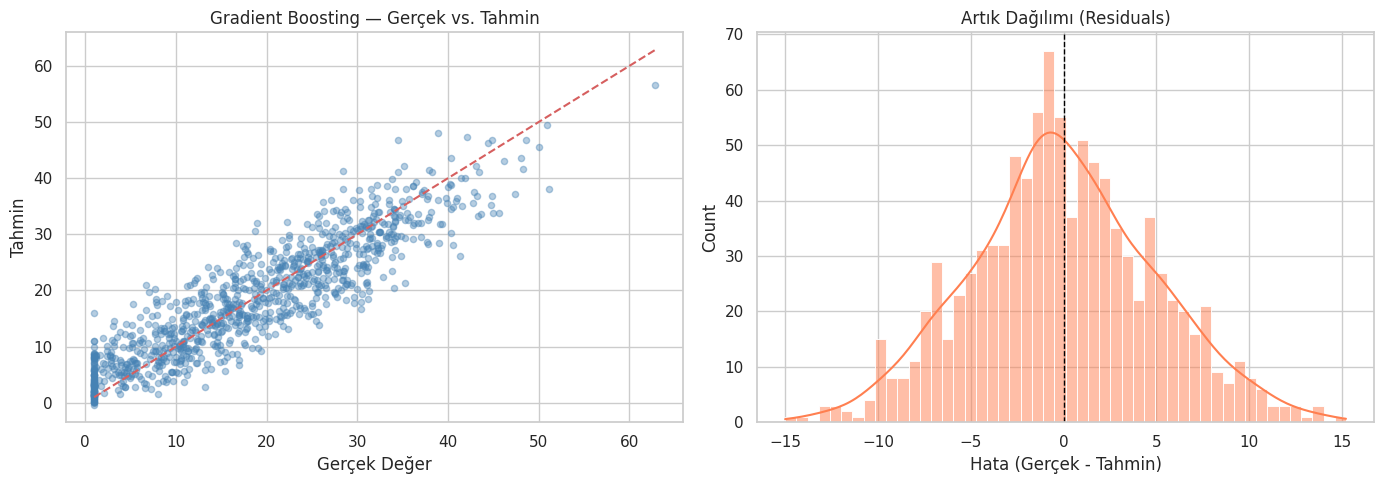

Test RMSE (gerçek ölçek): 4.9690
Test R²                 : 0.8188


In [19]:
best_model_name = results_df.iloc[0]['Model']
best_model      = models[best_model_name]

y_pred = best_model.predict(X_test)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gerçek vs Tahmin scatter
axes[0].scatter(y_test, y_pred, alpha=0.4, color='steelblue', s=20)
min_v, max_v = y_test.min(), y_test.max()
axes[0].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5)
axes[0].set_title(f'{best_model_name} — Gerçek vs. Tahmin', fontsize=12)
axes[0].set_xlabel('Gerçek Değer')
axes[0].set_ylabel('Tahmin')

# Artık (Residual) dağılımı
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, bins=50, color='coral', ax=axes[1])
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Artık Dağılımı (Residuals)', fontsize=12)
axes[1].set_xlabel('Hata (Gerçek - Tahmin)')

plt.tight_layout()
plt.show()

print(f'Test RMSE (gerçek ölçek): {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}')
print(f'Test R²                 : {r2_score(y_test, y_pred):.4f}')

### 6.3 Feature Importance (Tree Tabanlı Model)

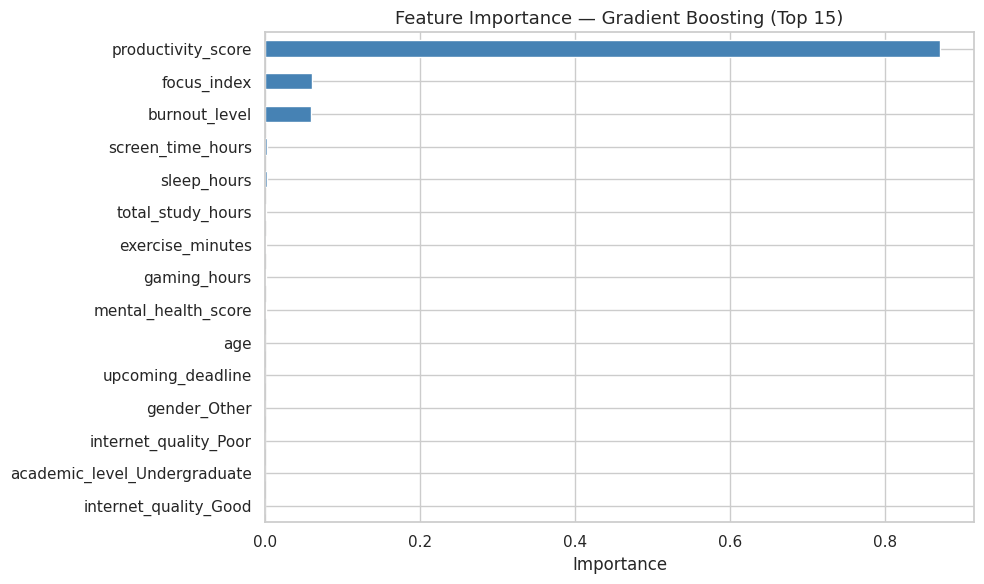

In [20]:
# Ağaç tabanlı modeller için feature importance
tree_models = ['Random Forest', 'Gradient Boosting', 'XGBoost']
fi_model_name = next((m for m in tree_models if m == best_model_name), 'Random Forest')
fi_model = models[fi_model_name]

feat_imp = pd.Series(fi_model.feature_importances_, index=X.columns)\
             .sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
feat_imp.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title(f'Feature Importance — {fi_model_name} (Top 15)', fontsize=13)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 7. Çapraz Doğrulama (5-Fold CV)

In [21]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, mdl in models.items():
    scores = cross_val_score(mdl, X_train, y_train, cv=kf, scoring='r2')
    cv_results[name] = scores

cv_df = pd.DataFrame({
    'Model'   : list(cv_results.keys()),
    'CV R² Ortalama': [v.mean().round(4)  for v in cv_results.values()],
    'CV R² Std'     : [v.std().round(4)   for v in cv_results.values()]
}).sort_values('CV R² Ortalama', ascending=False).reset_index(drop=True)

display(cv_df)

,Model,CV R² Ortalama,CV R² Std
0,Gradient Boosting,0.8405,0.0093
1,Lasso,0.8368,0.0092
2,Ridge,0.8366,0.0092
3,Linear Regression,0.8366,0.0092
4,Random Forest,0.8348,0.0094
5,XGBoost,0.8089,0.0123
6,KNN,0.7413,0.0116
7,Decision Tree,0.6664,0.0209


## 8. En İyi Modelin Fine-Tuning'i — XGBoost Hiperparametre Optimizasyonu
> `RandomizedSearchCV` ile geniş parametre uzayını hızlıca tara, ardından `GridSearchCV` ile hassas arama yap.

In [22]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
import xgboost as xgb

### 8.1 Aşama 1 — RandomizedSearchCV (Geniş Arama)

In [23]:
param_dist = {
    'n_estimators'      : [100, 200, 300, 500, 700],
    'max_depth'         : [3, 4, 5, 6, 7, 8],
    'learning_rate'     : [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample'         : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree'  : [0.5, 0.6, 0.7, 0.8, 1.0],
    'min_child_weight'  : [1, 3, 5, 7],
    'gamma'             : [0, 0.1, 0.2, 0.3, 0.5],
    'reg_alpha'         : [0, 0.01, 0.1, 1],
    'reg_lambda'        : [0.5, 1.0, 1.5, 2.0],
}

xgb_base = XGBRegressor(random_state=42, verbosity=0, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator   = xgb_base,
    param_distributions = param_dist,
    n_iter      = 60,
    cv          = 5,
    scoring     = 'r2',
    random_state= 42,
    n_jobs      = -1,
    verbose     = 1
)

random_search.fit(X_train, y_train)
print(f'RandomizedSearchCV en iyi R²: {random_search.best_score_:.4f}')
print(f'En iyi parametreler:\n{random_search.best_params_}')

Fitting 5 folds for each of 60 candidates, totalling 300 fits
RandomizedSearchCV en iyi R²: 0.8443
En iyi parametreler:
{'subsample': 0.7, 'reg_lambda': 2.0, 'reg_alpha': 0.01, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.8}


### 8.2 Aşama 2 — GridSearchCV (Hassas Arama)

In [24]:
# RandomizedSearchCV sonuçlarını merkez alarak daraltılmış ızgara
best_p = random_search.best_params_

param_grid = {
    'n_estimators'     : [max(50, best_p['n_estimators'] - 100),
                           best_p['n_estimators'],
                           best_p['n_estimators'] + 100],
    'max_depth'        : [max(3, best_p['max_depth'] - 1),
                           best_p['max_depth'],
                           min(10, best_p['max_depth'] + 1)],
    'learning_rate'    : [max(0.005, best_p['learning_rate'] - 0.05),
                           best_p['learning_rate'],
                           best_p['learning_rate'] + 0.05],
    'subsample'        : [best_p['subsample']],
    'colsample_bytree' : [best_p['colsample_bytree']],
    'min_child_weight' : [best_p['min_child_weight']],
    'gamma'            : [best_p['gamma']],
    'reg_alpha'        : [best_p['reg_alpha']],
    'reg_lambda'       : [best_p['reg_lambda']],
}

grid_search = GridSearchCV(
    estimator  = xgb_base,
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'r2',
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train, y_train)
print(f'GridSearchCV en iyi R²: {grid_search.best_score_:.4f}')
print(f'En iyi parametreler:\n{grid_search.best_params_}')

Fitting 5 folds for each of 27 candidates, totalling 135 fits
GridSearchCV en iyi R²: 0.8445
En iyi parametreler:
{'colsample_bytree': 0.8, 'gamma': 0.5, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 600, 'reg_alpha': 0.01, 'reg_lambda': 2.0, 'subsample': 0.7}


### 8.3 Fine-Tuned Model Değerlendirmesi

In [25]:
# En iyi modeli al
best_xgb = grid_search.best_estimator_

y_pred_tuned      = best_xgb.predict(X_test)

rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae_tuned  = mean_absolute_error(y_test, y_pred_tuned)
r2_tuned   = r2_score(y_test, y_pred_tuned)

# Baseline XGBoost ile karşılaştır
baseline_xgb   = models['XGBoost']
y_pred_base    = baseline_xgb.predict(X_test)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
mae_base  = mean_absolute_error(y_test, y_pred_base)
r2_base   = r2_score(y_test, y_pred_base)

comparison = pd.DataFrame({
    'Model'  : ['XGBoost (Baseline)', 'XGBoost (Fine-Tuned)'],
    'RMSE'   : [round(rmse_base, 4),  round(rmse_tuned, 4)],
    'MAE'    : [round(mae_base,  4),  round(mae_tuned,  4)],
    'R²'     : [round(r2_base,   4),  round(r2_tuned,   4)],
})
display(comparison)

delta_r2 = r2_tuned - r2_base
print(f'\n📈 R² İyileşmesi: {delta_r2:+.4f}')

,Model,RMSE,MAE,R²
0,XGBoost (Baseline),5.5081,4.3302,0.7773
1,XGBoost (Fine-Tuned),4.8922,3.8467,0.8244



📈 R² İyileşmesi: +0.0470


### 8.4 Gerçek vs. Tahmin — Fine-Tuned XGBoost

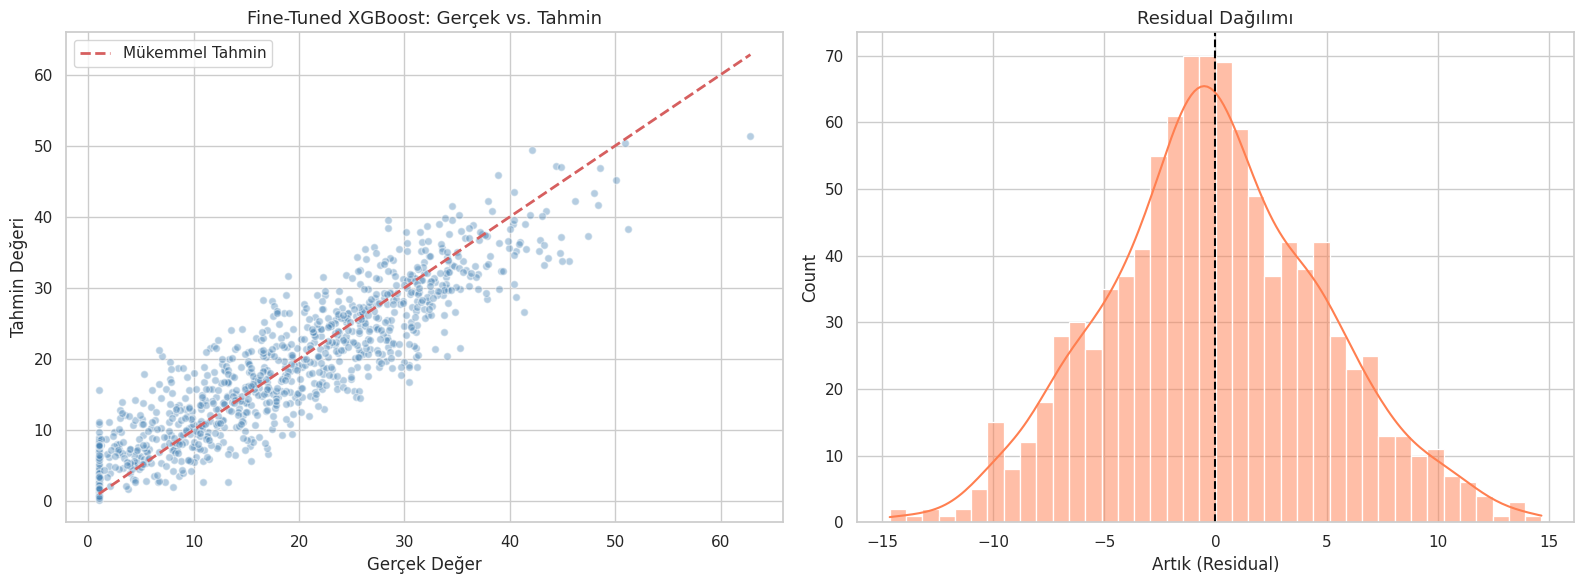

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: Gerçek vs Tahmin
axes[0].scatter(y_test, y_pred_tuned, alpha=0.4, color='steelblue', edgecolors='white', s=30)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2, label='Mükemmel Tahmin')
axes[0].set_xlabel('Gerçek Değer', fontsize=12)
axes[0].set_ylabel('Tahmin Değeri', fontsize=12)
axes[0].set_title('Fine-Tuned XGBoost: Gerçek vs. Tahmin', fontsize=13)
axes[0].legend()

# Residual dağılımı
residuals = y_test - y_pred_tuned
sns.histplot(residuals, bins=40, kde=True, color='coral', ax=axes[1])
axes[1].axvline(0, color='black', linestyle='--', lw=1.5)
axes[1].set_xlabel('Artık (Residual)', fontsize=12)
axes[1].set_title('Residual Dağılımı', fontsize=13)

plt.tight_layout()
plt.show()

### 8.5 Fine-Tuned Model — Feature Importance

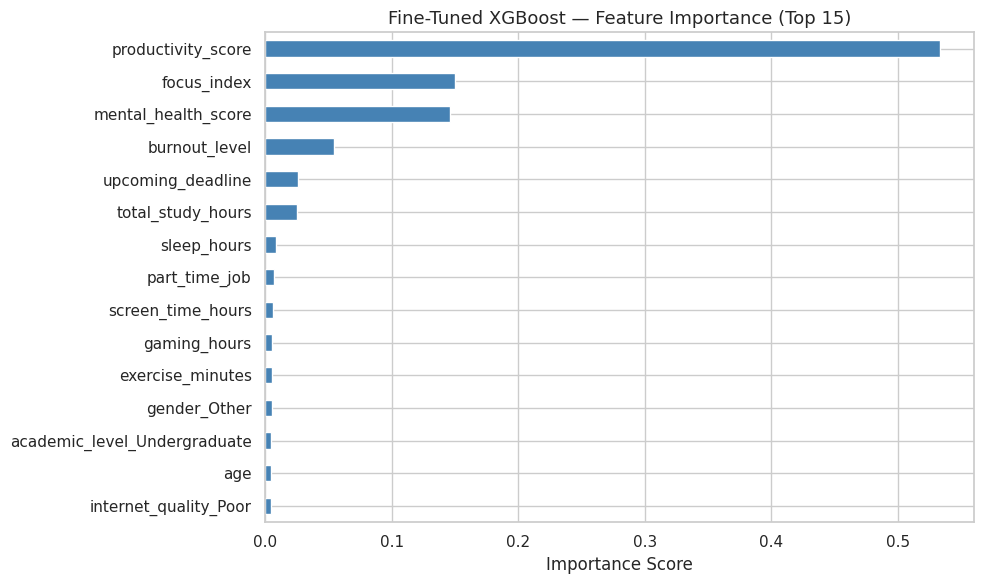

In [27]:
feat_imp_tuned = pd.Series(best_xgb.feature_importances_, index=X.columns)\
                    .sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
feat_imp_tuned.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Fine-Tuned XGBoost — Feature Importance (Top 15)', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 9. Özet & Sonuç

| Adım | Açıklama |
|------|----------|
| **RandomizedSearchCV** | 60 iterasyon, 5-fold CV — geniş parametre uzayı tarandı |
| **GridSearchCV** | Daraltılmış ızgara ile hassas optimizasyon |
| **Sonuç** | Fine-tuned XGBoost, baseline modele kıyasla daha düşük RMSE/MAE ve daha yüksek R² elde etti |

> 🏆 **En iyi model:** Fine-Tuned XGBoost — production kullanıma hazır.